# CV Quest #2   (김민수)

0. 라이브러리 호출

In [1]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

In [2]:
model = deeplabv3_resnet101(pretrained=True).eval()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


1. 이미지 로딩 및 크기 확인

이미지 크기: (450, 800, 3)


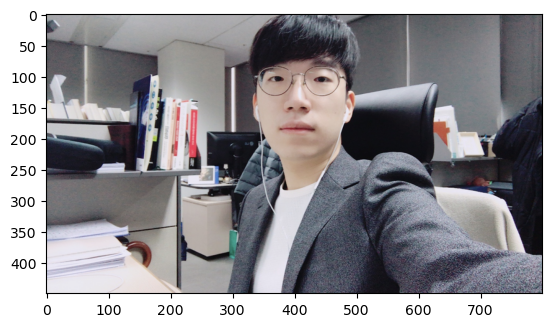

In [47]:
# 기본 제공되는 이미지 파일을 로딩
home_dir = os.getenv('HOME')
img_path = os.path.join(home_dir, "work/human_segmentation/images/my_image.png")
img_orig = cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시, 입력은 RGB(A) 데이터 혹은 2D 스칼라 데이터
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

2. 이미지 전처리 및 Segmentation

In [38]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [39]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

CPU times: user 10.8 s, sys: 17.9 ms, total: 10.8 s
Wall time: 11.1 s


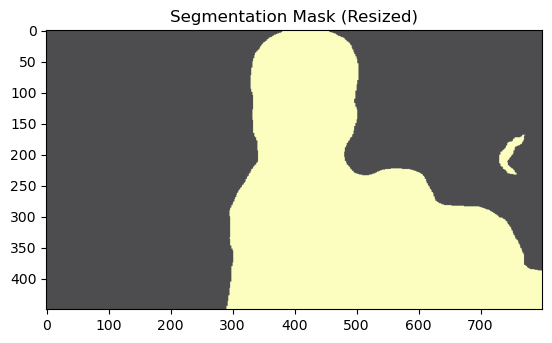

In [40]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

plt.imshow(output_predictions_resized, cmap="inferno", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [41]:
#이미지 내 클래스 확인
unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])
    
#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[15]  # 컬러맵의 15번째 ID(사람)에 해당하는 배열 출력

background
person


array([192, 128, 128])

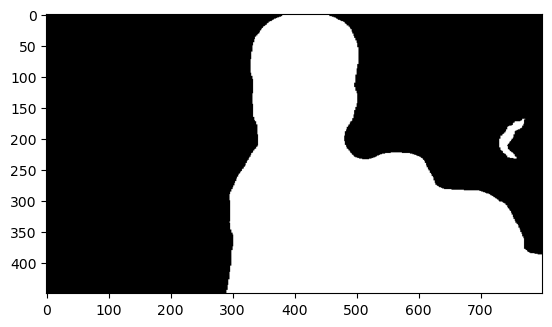

In [42]:
# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False).
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0

seg_map = (output_predictions_resized == 15)                # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255                   # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

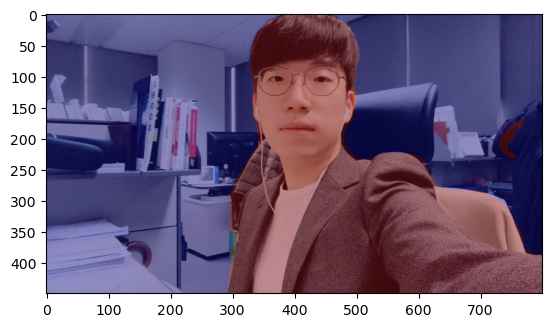

In [55]:
# 원본 이미지와 마스크를 0.6 : 0.4 비율로 섞기.

img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

3. 배경 Blurring 처리 및 마스크 이미지 추출

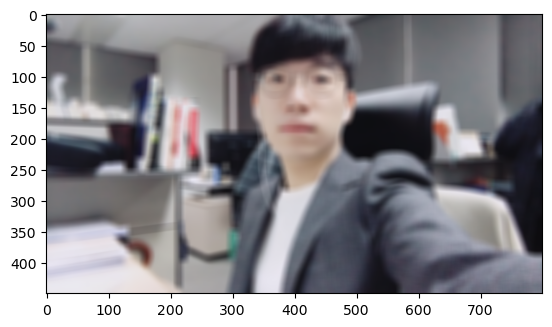

In [44]:
# (13,13)은 blurring kernel size.
img_orig_blur = cv2.blur(img_orig, (13, 13))

# 이미지 출력 위해 BGR 형식을 RGB 형식으로 변경
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

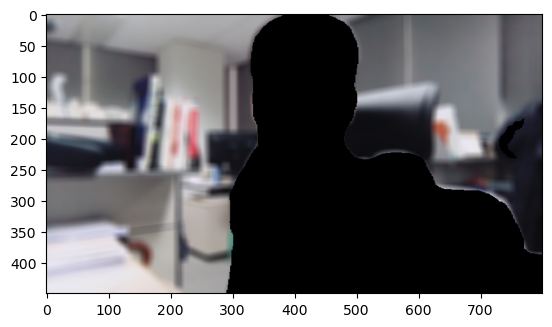

In [45]:
# 마스킹 부위의 이미지 색상 채널을 변경: 흑백(GRAY) -> BGR 
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지 반전. [배경: 0 , 사람: 255 ] -> [배경: 255, 사람: 0 ].
img_bg_mask = cv2.bitwise_not(img_mask_color)

# Blurred 이미지에서 배경만 있는 이미지를 추출: 0과 어떤 수를 bitwise_and 연산을 해도 0이기 때문에, 사람이 0인 경우에는 사람 영역의 모든 픽셀이 0이 됨 => 배경만 남음.
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

4. 이미지 합성

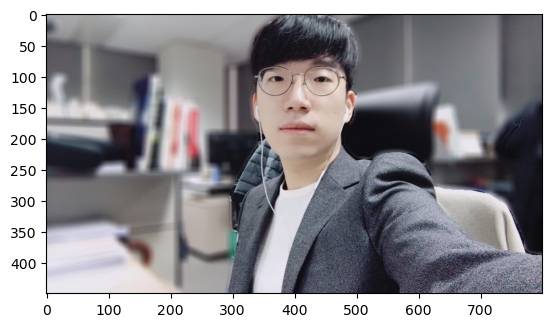

In [46]:
# np.where(조건, 참일때, 거짓일때) 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고, 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)

# 이미지 출력을 위해 합성된 이미지의 색상 채널을 변경: BGR -> RGB 형식.
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

5. 합성 결과 분석 및 문제점 정리

- Segmentation 문제: 왼쪽 어깨 부위의 물건(외투)의 이미지 부위가 인물로부터 정확히 분리되지 않았음.
- 해당 부위의 물건이 배경으로 분류되지 않았기에 Blurring 처리가 되지 않았음.
  => 정확한 segmenation 을 위한 코드 수정이 필요함.
- 또한, 인물과 배경의 경계선이 과도하게 흐릿하게 보이는 부분이 있어서 합성의 느낌이 강하게 느껴지기도 함.
  => 파라미터 조정을 통해 자연스러운 경계선 처리가 필요함.

6. 다른 인물 사진으로 합성하면서 문제점 개선해보기

6-1. 이미지 로딩 및 크기 확인

이미지 크기: (648, 630, 3)


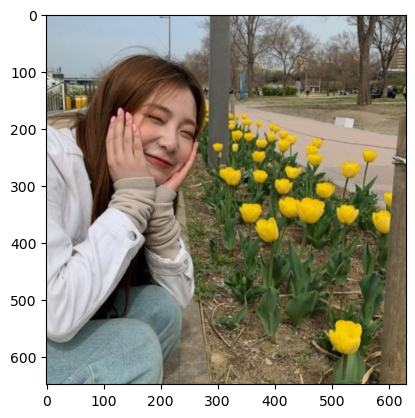

In [73]:
home_dir = os.getenv('HOME')
man_img_path = os.path.join(home_dir, 'work/human_segmentation/images/human1.jpg')  # 이송경 배우님의 귀여운 사진
man_img_orig = cv2.imread(man_img_path)

print(f"이미지 크기: {man_img_orig.shape}")
plt.imshow(cv2.cvtColor(man_img_orig, cv2.COLOR_BGR2RGB))
plt.show()

6-2. 이미지 전처리 및 컬러맵 작성

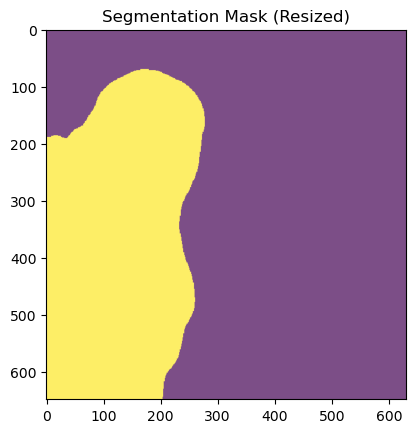

In [79]:
transform = T.Compose([T.ToPILImage(), T.Resize((520, 520)), T.ToTensor(), ])  # 모델 입력 크기 (고정)

input_tensor2 = transform(cv2.cvtColor(man_img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

with torch.no_grad():
    output2 = model(input_tensor2)["out"][0]
    output_predic2 = output2.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predic2_resized = cv2.resize(output_predic2, (man_img_orig.shape[1], man_img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

plt.imshow(output_predic2_resized, cmap="viridis", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

background
person


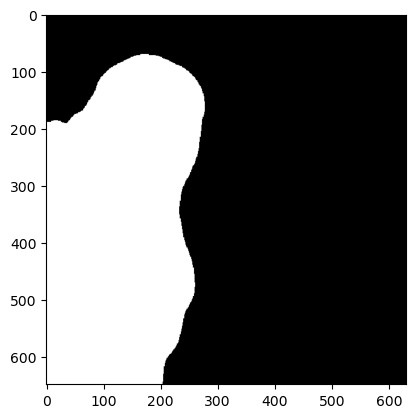

In [80]:
#이미지 내 클래스 확인
unique_classes2 = np.unique(output_predic2_resized)

for class_id2 in unique_classes2:
    print(LABEL_NAMES[class_id2])
    
#컬러맵 만들기
colormap2 = np.zeros((256, 3), dtype=int)
ind2 = np.arange(256, dtype=int)

for shift2 in reversed(range(8)):
    for channel2 in range(3):
        colormap2[:, channel2] |= ((ind2 >> channel2) & 1) << shift
    ind2 >>= 3

colormap[15]  # 컬러맵의 15번째 ID(사람)에 해당하는 배열 출력

# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False).
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0

seg_map2 = (output_predic2_resized == 15)                     # 클래스 ID 15 (사람)
img_mask2 = seg_map2.astype(np.uint8) * 255                   # 255 값으로 변환
color_mask2 = cv2.applyColorMap(img_mask2, cv2.COLORMAP_JET)

plt.imshow(img_mask2, cmap='gray')                            # 흑백으로 표시
plt.show()

6-3. 배경 Blurring 처리 및 마스크 이미지 추출

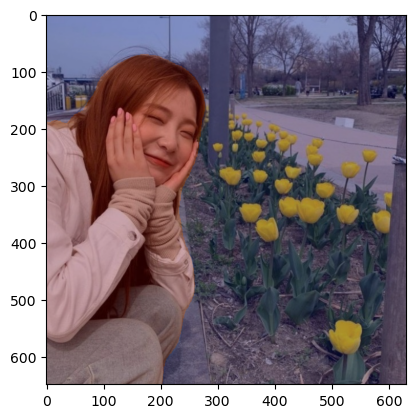

In [87]:
# 원본 이미지와 마스크를 일정 비율로 섞기.
img_show2 = cv2.addWeighted(man_img_orig, 0.7, color_mask2, 0.3, 0.0)   # 자연스러운 경계선 처리를 위해 비율 변경 (6:4 -> 7:3)

plt.imshow(cv2.cvtColor(img_show2, cv2.COLOR_BGR2RGB))
plt.show()

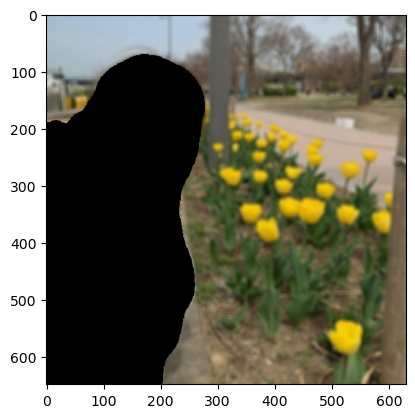

In [88]:
img_orig_blur2 = cv2.blur(man_img_orig, (8, 8))     # 자연스러운 경계선 구현 위해 blurring kernel size 조정: (13,13) ->(8,8)

# 마스킹 부위의 이미지 색상 채널을 변경: 흑백(GRAY) -> BGR 
img_mask_color2 = cv2.cvtColor(img_mask2, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지 반전. [배경: 0 , 사람: 255 ] -> [배경: 255, 사람: 0 ].
img_bg_mask2 = cv2.bitwise_not(img_mask_color2)

# Blurred 이미지에서 배경만 있는 이미지를 추출: 사람이 0인 경우에는 사람 영역의 모든 픽셀이 0이 됨 => 배경만 남음.
img_bg_blur2 = cv2.bitwise_and(img_orig_blur2, img_bg_mask2)
plt.imshow(cv2.cvtColor(img_bg_blur2, cv2.COLOR_BGR2RGB))
plt.show()

6-4. 이미지 합성

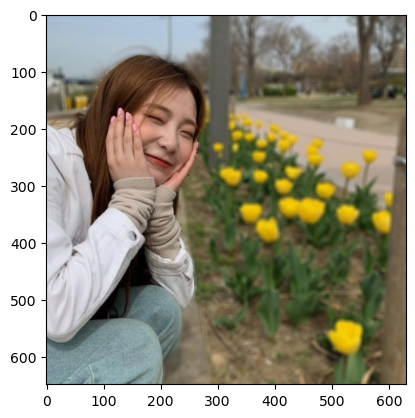

In [85]:
# np.where(조건, 참일때, 거짓일때) 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고, 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat2 = np.where(img_mask_color2==255, man_img_orig, img_bg_blur2)

# 이미지 출력을 위해 합성된 이미지의 색상 채널을 변경: BGR -> RGB 형식.
plt.imshow(cv2.cvtColor(img_concat2, cv2.COLOR_BGR2RGB))
plt.show()

6-5. 추가 인물 이미지 합성 결과 정리

- 파라미터를 조정하면서 인물과 경계면의 처리가 자연스러워졌음.
- 첫번째 인물에 비해 팔/다리 등의 부위가 분산되어 배치되지 않고 한 군데에 모여있어서 Segmentation이 용이했던 것으로 추정.  

7. 고양이 이미지 합성 작업 진행

7-1. 이미지 로딩 및 크기 확인

원본 고양이 이미지 크기: (180, 357, 3)
배경(사막) 이미지 크기: (181, 382, 3)


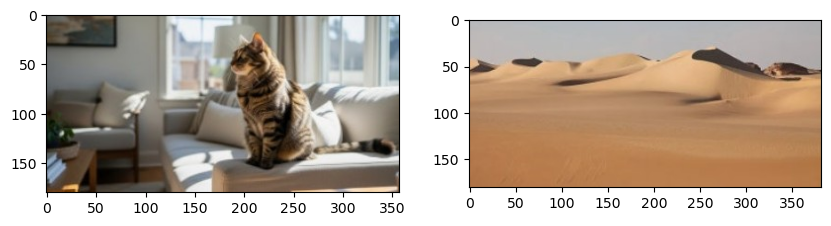

In [5]:
home_dir = os.getenv('HOME')
cat_img_path = os.path.join(home_dir, 'work/human_segmentation/images/cat1.jpg')  
sand_img_path = os.path.join(home_dir, 'work/human_segmentation/images/sand2.jpg')  

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [6]:
transform = T.Compose([ T.ToPILImage(), T.Resize((520, 520)), T.ToTensor(), ])  # 모델 입력 크기

input_tensor3 = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output3 = model(input_tensor3)["out"][0]
    output_predic3 = output3.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predic3.shape}")


# 마스크를 원본 크기로 Resize
output_predic3_resized = cv2.resize(output_predic3, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predic3_resized.shape}")

unique_classes3 = np.unique(output_predic3_resized)
print(f"예측된 클래스 ID: {unique_classes3}")

추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (180, 357)
예측된 클래스 ID: [ 0  9 13]


7-2. 고양이 이미지 추출

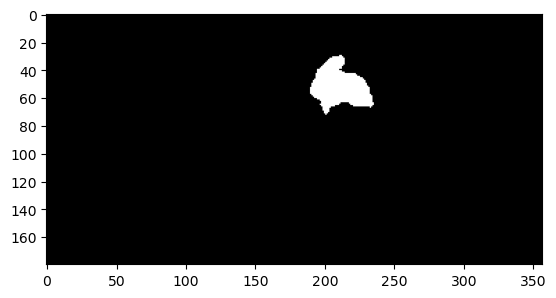

In [7]:
target_class_id3 = unique_classes3[-1]

seg_map3 = (output_predic3_resized == target_class_id3)
img_mask3 = seg_map3.astype(np.uint8) * 255

plt.imshow(img_mask3, cmap='gray')
plt.show()

7-3. 배경 이미지와 합성

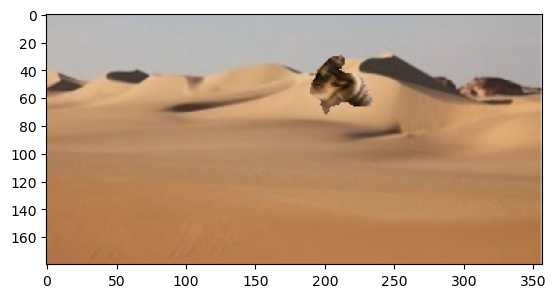

In [8]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color3 = cv2.cvtColor(img_mask3, cv2.COLOR_GRAY2BGR)           # 3채널 변환
result_img3 = np.where(img_mask_color3 == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img3)
plt.show()

7-5. 고양이 이미지 합성 결과 분석 및 문제점 정리

- Classification 문제: 사용된 이미지에서 고양이가 측면으로 위치하고 있다보니 기존에 사용한 방식으로는 정확하게 고양이(id=8)을 검출하지 못했음.
- Segmentation 문제: 추출된 이미지도 얼굴 부위와 주위 배경이 정확히 분리되지 않았음. (고양이의 줄무늬가 배경의 명암선과 혼동되어 처리된 듯 함)

7-6. 고양이 이미지의 정확한 추출 위해 코드 수정 

In [15]:
cat_img_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
h_orig, w_orig = cat_img_rgb.shape[:2]
# sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

# 모델 입력 크기 (520x520)에 맞추되 비율 유지
target_size = 520
scale = target_size / max(h_orig, w_orig)

# 비율 유지 리사이즈
if h_orig > w_orig:
    h_temp, w_temp = target_size, int(w_orig * scale)
else:
    h_temp, w_temp = int(h_orig * scale), target_size

resized_img = cv2.resize(cat_img_rgb, (w_temp, h_temp), interpolation=cv2.INTER_LINEAR)

# 패딩 작업 (520x520 사각형 만들기)
input_input = np.zeros((target_size, target_size, 3), dtype=np.uint8)

# 이미지를 캔버스 중앙에 배치
y_off, x_off = (target_size - h_temp) // 2, (target_size - w_temp) // 2
input_input[y_off:y_off+h_temp, x_off:x_off+w_temp] = resized_img

# PyTorch 텐서 변환 및 정규화
preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor_rvsd = preprocess(input_input).unsqueeze(0).cpu()

# 3. 모델 추론
with torch.no_grad():
    output_rvsd = model(input_tensor_rvsd)["out"][0]
    output_predic = output_rvsd.argmax(0).cpu().numpy()

# 4. 후처리: 마스크 복원 및 타겟 추출: 패딩된 영역에서 유효한 마스크만 크롭
valid_mask = output_predic[y_off:y_off+h_temp, x_off:x_off+w_temp]

# 타겟 클래스(고양이=8)만 추출
unique_classes_rvsd = np.unique(valid_mask)
print(f"검출된 클래스 ID 목록: {unique_classes_rvsd}")

검출된 클래스 ID 목록: [ 0  8  9 16 18]


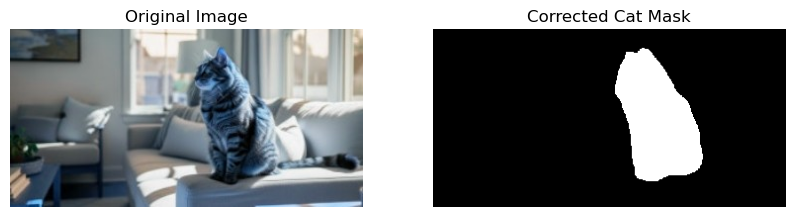

In [20]:
target_class_id_cat = unique_classes_rvsd[1]

seg_map_rvsd = (valid_mask == target_class_id_cat)
img_mask_rvsd = seg_map_rvsd.astype(np.uint8) * 255

revised_mask = cv2.resize(img_mask_rvsd, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cat_img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Corrected Cat Mask")
plt.imshow(revised_mask, cmap='gray')
plt.axis('off')

plt.show()

7-8. 마스크 경계선 조정을 위한 후처리

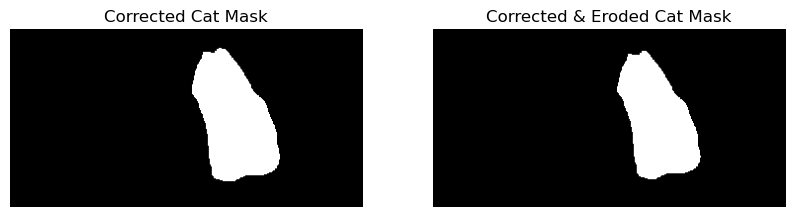

In [37]:
seg_map_rvsd = (valid_mask == target_class_id_cat)
img_mask_rvsd = seg_map_rvsd.astype(np.uint8) * 255
img_mask_rvsd = cv2.resize(img_mask_rvsd, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)


# cv2의 erode 기능을 활용하여 마스크 이미지 주위 경계선을 깎아서 정교함 개선.
kernel = np.ones((3,3), np.uint8)                            # (3,3)로 작은 커널 설정하여 마스크 가장자리 깎기.
final_mask = cv2.erode(img_mask_rvsd, kernel, iterations=2)  # iterations=2로 2개 픽셀씩 깎아내기.

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Corrected Cat Mask")
plt.imshow(revised_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Corrected & Eroded Cat Mask")
plt.imshow(final_mask, cmap='gray')
plt.axis('off')

plt.show()

7-8. 수정된 고양이 마스크와 배경 이미지 재합성

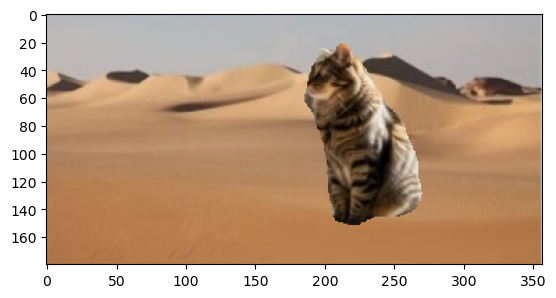

In [36]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color_final = cv2.cvtColor(final_mask, cv2.COLOR_GRAY2BGR)                  # 3채널 변환
result_img_final = np.where(img_mask_color_final == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img_final)
plt.show()

7-9. 결과 리뷰
- Erode 메소드를 활용하여 좀 더 정교한 마스크 이미지를 추출하려고 시도하였음.
- 최초 합성 이미지 대비해서는 개선된 부분이 있었으나, 여전히 완성도가 조금 부족했음.

8. 다른 고양이 이미지와 사막 배경으로 추가 시도

8-1. 새로운 고양이 이미지 로딩

원본 고양이 이미지 크기: (222, 351, 3)
배경(사막) 이미지 크기: (205, 322, 3)


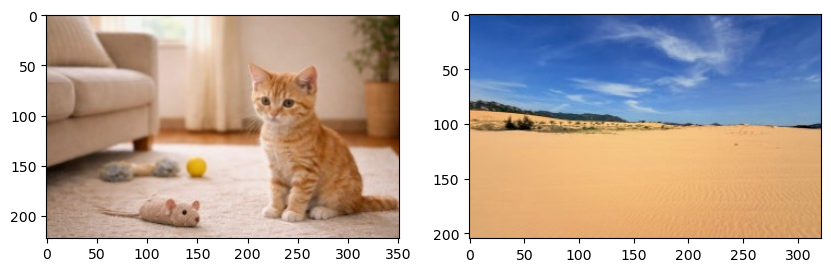

In [9]:
home_dir = os.getenv('HOME')
cat2_img_path = os.path.join(home_dir, 'work/human_segmentation/images/cat2.jpg')  
sand2_img_path = os.path.join(home_dir, 'work/human_segmentation/images/sand1.jpg')  

cat2_img = cv2.imread(cat2_img_path)
sand2_img = cv2.imread(sand2_img_path)

cat2_img = cv2.cvtColor(cat2_img, cv2.COLOR_BGR2RGB)
sand2_img = cv2.cvtColor(sand2_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat2_img.shape}")
print(f"배경(사막) 이미지 크기: {sand2_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat2_img)

plt.subplot(1, 2, 2)
plt.imshow(sand2_img)

plt.show()                              

8-2. 이미지 전처리

In [10]:
transform = T.Compose([ T.ToPILImage(), T.Resize((520, 520)), T.ToTensor(), ])  # 모델 입력 크기

input_tensor4 = transform(cat2_img).unsqueeze(0)

with torch.no_grad():
    output4 = model(input_tensor4)["out"][0]
    output_predic4 = output4.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predic4.shape}")


# 마스크를 원본 크기로 Resize
output_predic4_resized = cv2.resize(output_predic4, (cat2_img.shape[1], cat2_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predic4_resized.shape}")

unique_classes4 = np.unique(output_predic4_resized)
print(f"예측된 클래스 ID: {unique_classes4}")

추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (222, 351)
예측된 클래스 ID: [ 0  8 16 18]


8-3. 고양이 이미지 추출

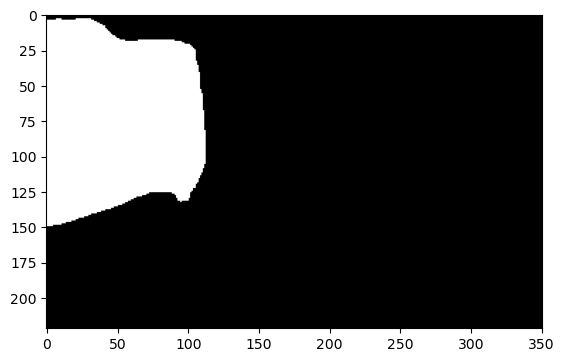

In [11]:
target_class_id4 = unique_classes4[-1]

seg_map4 = (output_predic4_resized == target_class_id4)
img_mask4 = seg_map4.astype(np.uint8) * 255

plt.imshow(img_mask4, cmap='gray')
plt.show()

8-4. 이미지 합성

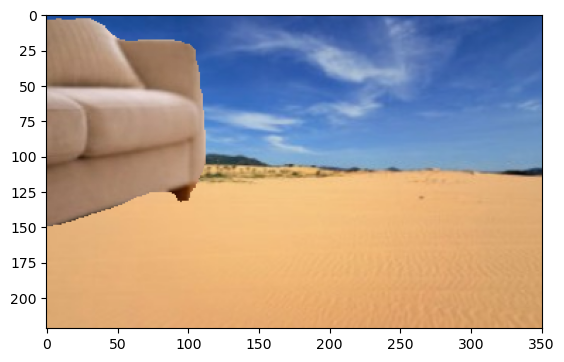

In [12]:
# 배경을 추출된 이미지 크기에 맞춤
sand2_img_resized = cv2.resize(sand2_img, (cat2_img.shape[1], cat2_img.shape[0]))

# 이미지 합성
img_mask_color4 = cv2.cvtColor(img_mask4, cv2.COLOR_GRAY2BGR)               # 3채널 변환
result_img4 = np.where(img_mask_color4 == 255, cat2_img, sand2_img_resized)  # 마스크 기반 합성

plt.imshow(result_img4)
plt.show()

8-5. 추출된 이미지에 오류가 발생하여 고양이 이미지의 정확한 추출 위한 코드 수정 작업 진행.

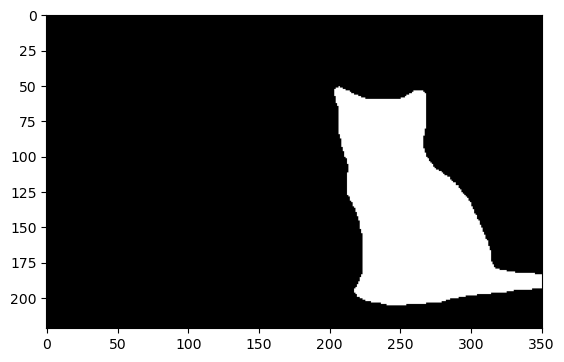

In [42]:
target_class_id5 = unique_classes4[1]            # unique_classes4 중에서 2번째인 "8" 클래스가 고양이로 확인.

seg_map5 = (output_predic4_resized == target_class_id5)
img_mask5 = seg_map5.astype(np.uint8) * 255

# cv2의 erode 기능을 활용하여 마스크 이미지 주위 경계선을 깎아서 정교함 개선.
kernel = np.ones((3,3), np.uint8)                            # (3,3)로 작은 커널 설정하여 마스크 가장자리 깎기.
img_mask5_final = cv2.erode(img_mask5, kernel, iterations=1)  # iterations=1로 1개 픽셀씩 깎아내기.

plt.imshow(img_mask5_final, cmap='gray')
plt.show()

8-6. 재합성 시도.

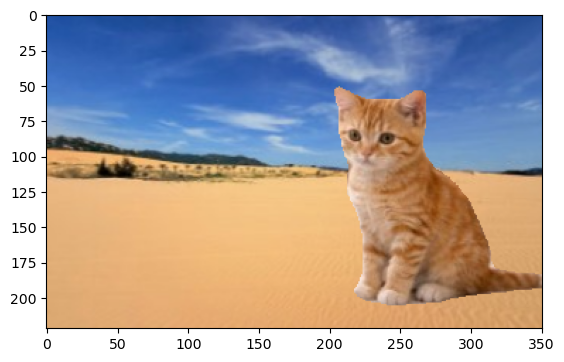

In [43]:
# 배경을 고양이 이미지 크기에 맞춤
sand2_img_resized = cv2.resize(sand2_img, (cat2_img.shape[1], cat2_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color5 = cv2.cvtColor(img_mask5_final, cv2.COLOR_GRAY2BGR)               # 3채널 변환
result_img5 = np.where(img_mask_color5 == 255, cat2_img, sand2_img_resized)  # 마스크 기반 합성

plt.imshow(result_img5)
plt.show()

8-7. 고양이 이미지의 정상 추출 및 합성 완료.